<a href="https://colab.research.google.com/github/MartinTiong/CPE-311/blob/main/Midterm_Quiz_2_Data_Analysis_using_Pandas_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
from google.colab import files
import kagglehub
import pandas as pd
import numpy as np
import os


In [65]:
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.


In [66]:
files = os.listdir(path)
print(files)

['RT_IOT2022.csv']


In [67]:
csv_path = os.path.join(path, 'RT_IOT2022.csv')
df = pd.read_csv(csv_path)

In [68]:
print( path)

/kaggle/input/rt-iot2022real-time-internet-of-things


Transform


In [69]:
df.head()


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [70]:
new= df.isnull()
print(new)

           no  id.orig_p  id.resp_p  proto  service  flow_duration  \
0       False      False      False  False    False          False   
1       False      False      False  False    False          False   
2       False      False      False  False    False          False   
3       False      False      False  False    False          False   
4       False      False      False  False    False          False   
...       ...        ...        ...    ...      ...            ...   
123112  False      False      False  False    False          False   
123113  False      False      False  False    False          False   
123114  False      False      False  False    False          False   
123115  False      False      False  False    False          False   
123116  False      False      False  False    False          False   

        fwd_pkts_tot  bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  \
0              False         False              False              False  ... 

In [71]:
new = df.dropna()
print(new)

          no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0          0      38667       1883   tcp    mqtt      32.011598             9   
1          1      51143       1883   tcp    mqtt      31.883584             9   
2          2      44761       1883   tcp    mqtt      32.124053             9   
3          3      60893       1883   tcp    mqtt      31.961063             9   
4          4      51087       1883   tcp    mqtt      31.902362             9   
...      ...        ...        ...   ...     ...            ...           ...   
123112  2005      59247      63331   tcp       -       0.000006             1   
123113  2006      59247      64623   tcp       -       0.000007             1   
123114  2007      59247      64680   tcp       -       0.000006             1   
123115  2008      59247      65000   tcp       -       0.000006             1   
123116  2009      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_d

In [72]:
clean = new.drop_duplicates()
print(clean)

          no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0          0      38667       1883   tcp    mqtt      32.011598             9   
1          1      51143       1883   tcp    mqtt      31.883584             9   
2          2      44761       1883   tcp    mqtt      32.124053             9   
3          3      60893       1883   tcp    mqtt      31.961063             9   
4          4      51087       1883   tcp    mqtt      31.902362             9   
...      ...        ...        ...   ...     ...            ...           ...   
123112  2005      59247      63331   tcp       -       0.000006             1   
123113  2006      59247      64623   tcp       -       0.000007             1   
123114  2007      59247      64680   tcp       -       0.000006             1   
123115  2008      59247      65000   tcp       -       0.000006             1   
123116  2009      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_d

In [73]:
clean = pd.get_dummies(clean, columns=['proto', 'service', 'Attack_type'], dtype=int)
print("After")
print(clean.shape)
print(clean.head())


After
(123117, 107)
   no  id.orig_p  id.resp_p  flow_duration  fwd_pkts_tot  bwd_pkts_tot  \
0   0      38667       1883      32.011598             9             5   
1   1      51143       1883      31.883584             9             5   
2   2      44761       1883      32.124053             9             5   
3   3      60893       1883      31.961063             9             5   
4   4      51087       1883      31.902362             9             5   

   fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  bwd_pkts_per_sec  \
0                  3                  3          0.281148          0.156193   
1                  3                  3          0.282277          0.156821   
2                  3                  3          0.280164          0.155647   
3                  3                  3          0.281593          0.156440   
4                  3                  3          0.282111          0.156728   

   ...  Attack_type_DOS_SYN_Hping  Attack_type_MQTT_Publish 

Load

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

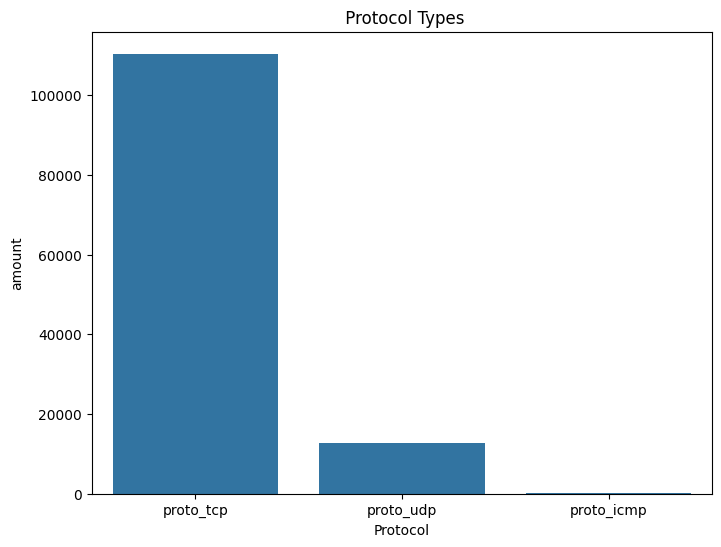

In [76]:
proto_cols = ['proto_tcp', 'proto_udp', 'proto_icmp']
proto_counts = clean[proto_cols].sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=proto_counts.index, y=proto_counts.values)
plt.title(' Protocol Types')
plt.xlabel('Protocol')
plt.ylabel('amount')
plt.show()

Statistical analysis

I used a bar plot to visualize the the distribution of the different protocol types and their count. From this visualization, we can see that the highest protocol is the proto tcp with more than 100,000, followed by the udp with less than 20,000, and the last is icmp with a very low count.